Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('charts', exist_ok=True)

df = pd.read_csv('cleaned_noshow_data.csv')
print("Shape:", df.shape)
print("No-show rate:", round(df['no_show_flag'].mean()*100, 1), "%")

Shape: (71954, 24)
No-show rate: 28.5 %


 Overall No-Show Distribution

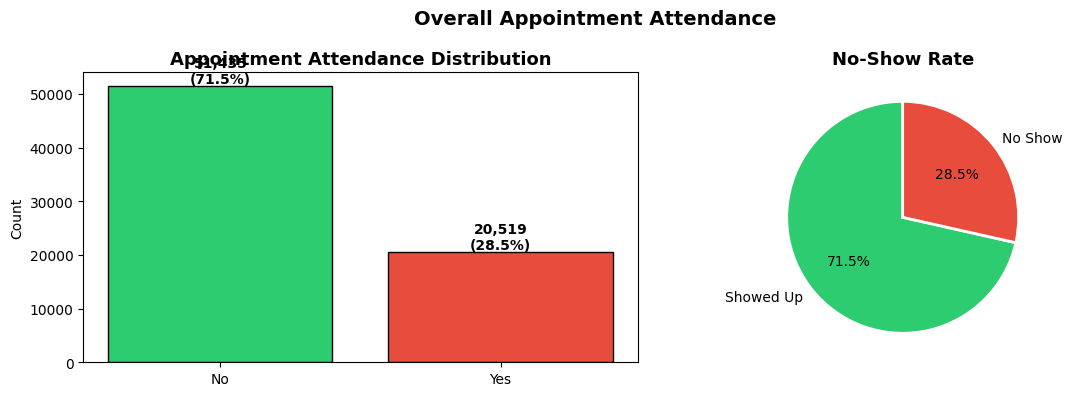

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['no_show'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Appointment Attendance Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Showed Up', 'No Show'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('No-Show Rate', fontsize=13, fontweight='bold')

plt.suptitle('Overall Appointment Attendance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/01_noshow_distribution.png', dpi=150)
plt.show()

 No-Show by Age Group

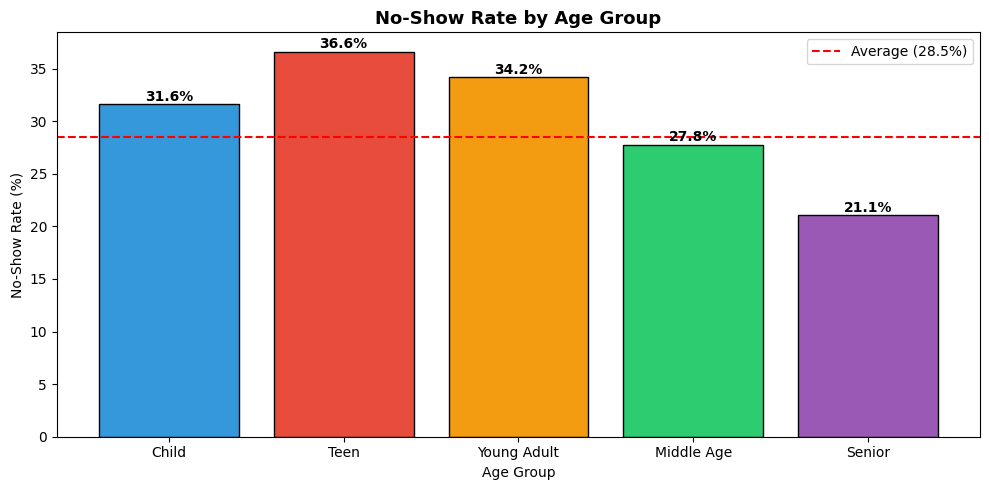

In [3]:
age_order = ['Child', 'Teen', 'Young Adult', 'Middle Age', 'Senior']
age_noshow = df.groupby('age_group')['no_show_flag'].mean() * 100
age_noshow = age_noshow.reindex(age_order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(age_noshow.index, age_noshow.values,
              color=['#3498db','#e74c3c','#f39c12','#2ecc71','#9b59b6'],
              edgecolor='black')
ax.set_title('No-Show Rate by Age Group', fontsize=13, fontweight='bold')
ax.set_ylabel('No-Show Rate (%)')
ax.set_xlabel('Age Group')
ax.axhline(df['no_show_flag'].mean()*100, color='red',
           linestyle='--', label=f'Average ({df["no_show_flag"].mean()*100:.1f}%)')
ax.legend()
for bar, val in zip(bars, age_noshow.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3, f'{val:.1f}%',
            ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/02_noshow_by_age.png', dpi=150)
plt.show()

 No-Show by Waiting Days

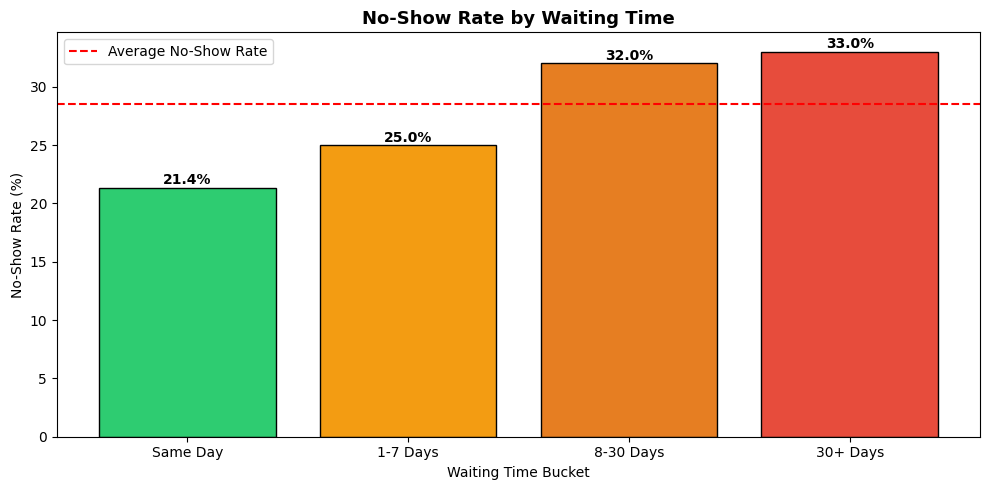

In [4]:
bucket_order = ['Same Day', '1-7 Days', '8-30 Days', '30+ Days']
wait_noshow = df.groupby('waiting_bucket')['no_show_flag'].mean() * 100
wait_noshow = wait_noshow.reindex(bucket_order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(wait_noshow.index, wait_noshow.values,
              color=['#2ecc71','#f39c12','#e67e22','#e74c3c'],
              edgecolor='black')
ax.set_title('No-Show Rate by Waiting Time', fontsize=13, fontweight='bold')
ax.set_ylabel('No-Show Rate (%)')
ax.set_xlabel('Waiting Time Bucket')
ax.axhline(df['no_show_flag'].mean()*100, color='red',
           linestyle='--', label='Average No-Show Rate')
ax.legend()
for bar, val in zip(bars, wait_noshow.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3, f'{val:.1f}%',
            ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('charts/03_noshow_by_waiting.png', dpi=150)
plt.show()

No-Show by SMS Received

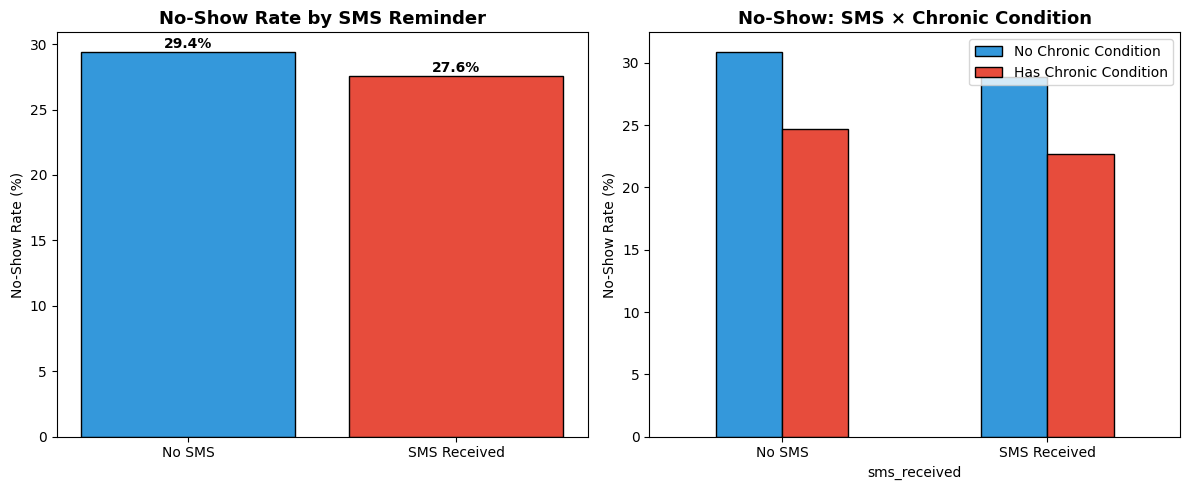

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sms_noshow = df.groupby('sms_received')['no_show_flag'].mean() * 100
sms_labels = ['No SMS', 'SMS Received']

axes[0].bar(sms_labels, sms_noshow.values,
            color=['#3498db','#e74c3c'], edgecolor='black')
axes[0].set_title('No-Show Rate by SMS Reminder', fontsize=13, fontweight='bold')
axes[0].set_ylabel('No-Show Rate (%)')
for i, v in enumerate(sms_noshow.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# SMS + Chronic condition combined
sms_chronic = df.groupby(['sms_received','has_chronic'])['no_show_flag'].mean() * 100
sms_chronic.unstack().plot(kind='bar', ax=axes[1],
                            color=['#3498db','#e74c3c'], edgecolor='black')
axes[1].set_title('No-Show: SMS × Chronic Condition', fontsize=13, fontweight='bold')
axes[1].set_ylabel('No-Show Rate (%)')
axes[1].set_xticklabels(['No SMS', 'SMS Received'], rotation=0)
axes[1].legend(['No Chronic Condition', 'Has Chronic Condition'])

plt.tight_layout()
plt.savefig('charts/04_noshow_sms.png', dpi=150)
plt.show()

No-Show by Day of Week

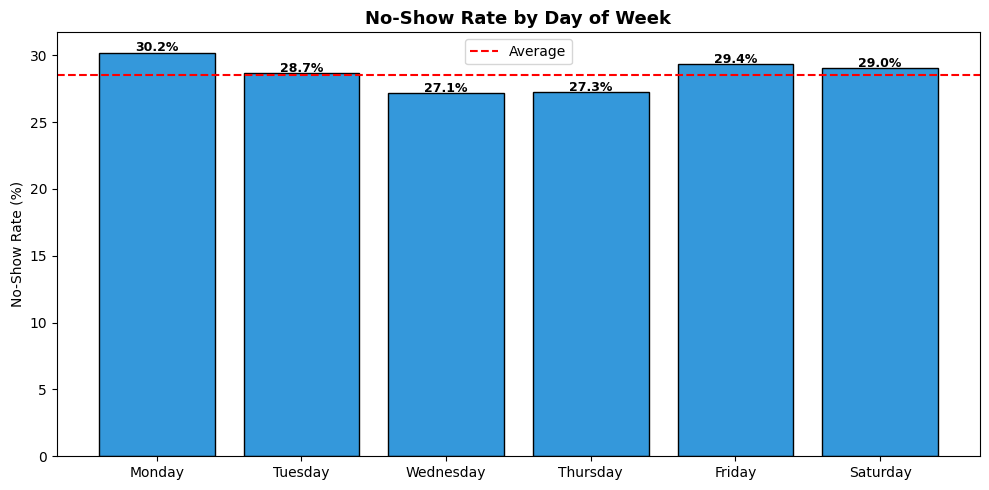

In [6]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
day_noshow = df.groupby('appointment_weekday')['no_show_flag'].mean() * 100
day_noshow = day_noshow.reindex(day_order).dropna()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(day_noshow.index, day_noshow.values,
              color='#3498db', edgecolor='black')
ax.set_title('No-Show Rate by Day of Week', fontsize=13, fontweight='bold')
ax.set_ylabel('No-Show Rate (%)')
ax.axhline(df['no_show_flag'].mean()*100, color='red',
           linestyle='--', label='Average')
ax.legend()
for bar, val in zip(bars, day_noshow.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1, f'{val:.1f}%',
            ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/05_noshow_by_day.png', dpi=150)
plt.show()

No-Show by Gender & Scholarship

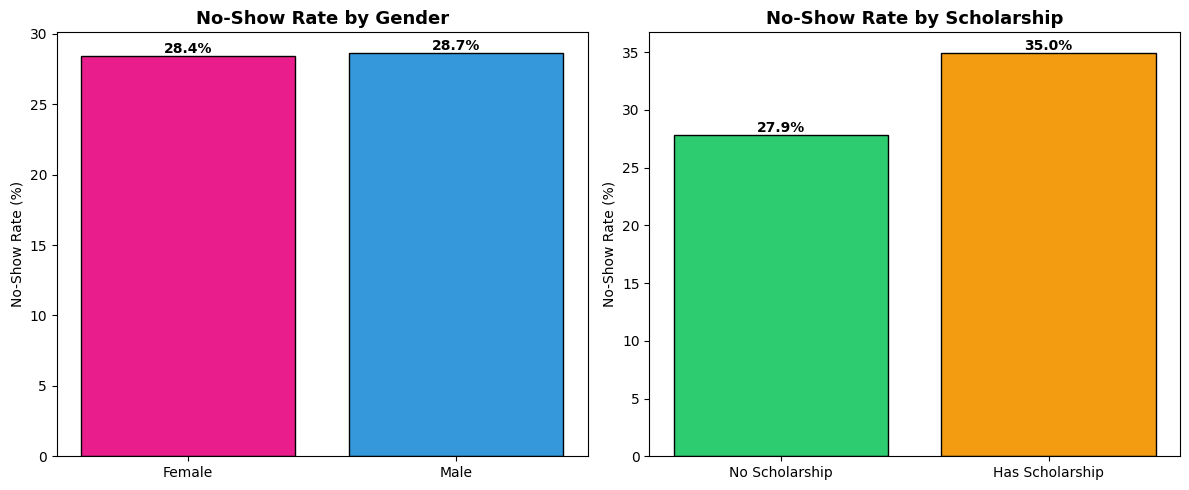

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gender_noshow = df.groupby('gender')['no_show_flag'].mean() * 100
axes[0].bar(['Female','Male'], gender_noshow.values,
            color=['#e91e8c','#3498db'], edgecolor='black')
axes[0].set_title('No-Show Rate by Gender', fontsize=13, fontweight='bold')
axes[0].set_ylabel('No-Show Rate (%)')
for i, v in enumerate(gender_noshow.values):
    axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

scholarship_noshow = df.groupby('scholarship')['no_show_flag'].mean() * 100
axes[1].bar(['No Scholarship','Has Scholarship'],
            scholarship_noshow.values,
            color=['#2ecc71','#f39c12'], edgecolor='black')
axes[1].set_title('No-Show Rate by Scholarship', fontsize=13, fontweight='bold')
axes[1].set_ylabel('No-Show Rate (%)')
for i, v in enumerate(scholarship_noshow.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/06_noshow_gender_scholarship.png', dpi=150)
plt.show()

Correlation Heatmap

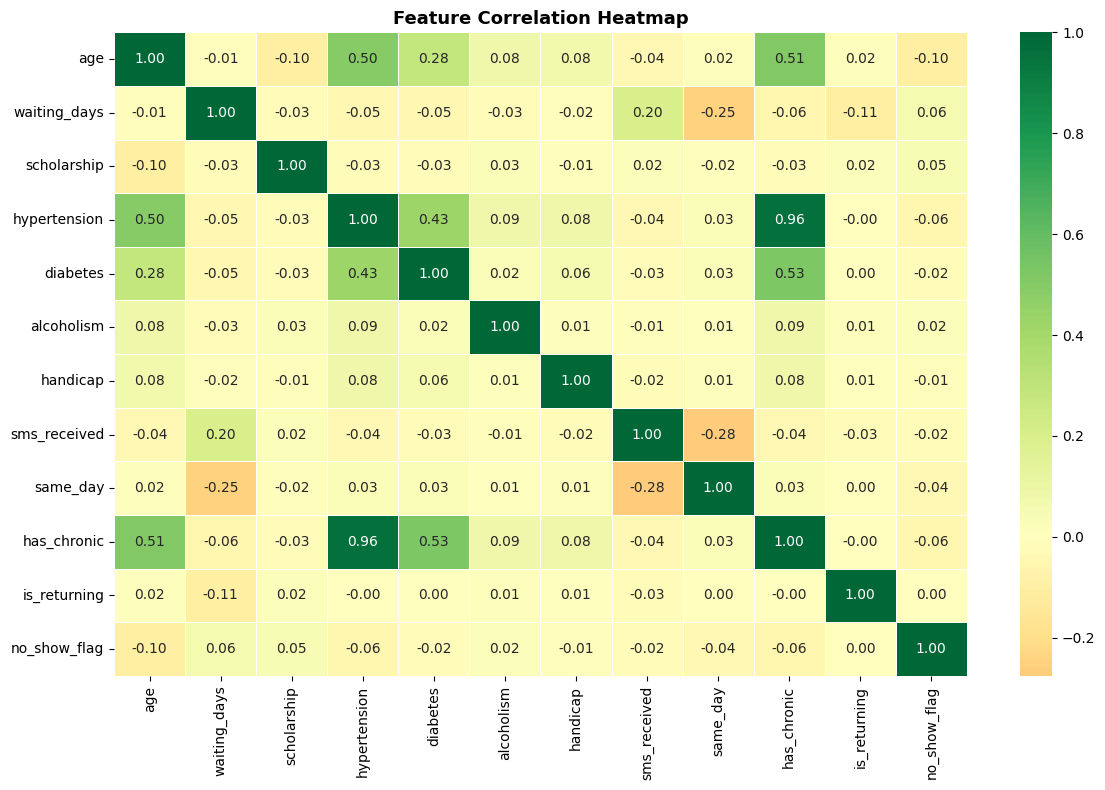

In [8]:
numeric_cols = ['age','waiting_days','scholarship','hypertension',
                'diabetes','alcoholism','handicap','sms_received',
                'same_day','has_chronic','is_returning','no_show_flag']

fig, ax = plt.subplots(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/07_correlation_heatmap.png', dpi=150)
plt.show()

Key Findings Summary

In [9]:
print("=" * 55)
print("   KEY EDA FINDINGS SUMMARY")
print("=" * 55)

overall_noshow = df['no_show_flag'].mean() * 100
print(f"\n📊 Overall No-Show Rate: {overall_noshow:.1f}%")
print(f"📋 Total Appointments: {len(df):,}")
print(f"❌ Total No-Shows: {df['no_show_flag'].sum():,}")

top_age = df.groupby('age_group')['no_show_flag'].mean().idxmax()
top_age_rate = df.groupby('age_group')['no_show_flag'].mean().max() * 100
print(f"\n👥 Highest No-Show Age Group: {top_age} ({top_age_rate:.1f}%)")

sms_yes = df[df['sms_received']==1]['no_show_flag'].mean()*100
sms_no = df[df['sms_received']==0]['no_show_flag'].mean()*100
print(f"\n📱 No-Show WITH SMS: {sms_yes:.1f}%")
print(f"📵 No-Show WITHOUT SMS: {sms_no:.1f}%")

wait_high = df[df['waiting_days'] > 30]['no_show_flag'].mean()*100
wait_low = df[df['waiting_days'] == 0]['no_show_flag'].mean()*100
print(f"\n⏰ No-Show (Same Day): {wait_low:.1f}%")
print(f"⏰ No-Show (30+ Days Wait): {wait_high:.1f}%")
print("=" * 55)

   KEY EDA FINDINGS SUMMARY

📊 Overall No-Show Rate: 28.5%
📋 Total Appointments: 71,954
❌ Total No-Shows: 20,519

👥 Highest No-Show Age Group: Teen (36.6%)

📱 No-Show WITH SMS: 27.6%
📵 No-Show WITHOUT SMS: 29.4%

⏰ No-Show (Same Day): 21.4%
⏰ No-Show (30+ Days Wait): 33.0%
